## PART 1 - Data Preparation

In [28]:
from google.colab import files

uploaded = files.upload()


Saving Microsoft_Stock.csv to Microsoft_Stock (3).csv


In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

df = pd.read_csv("Microsoft_Stock.csv")
df.head()

,Date,Open,High,Low,Close,Volume
0,4/1/2015 16:00:00,40.60,40.76,40.31,40.72,36865322
1,4/2/2015 16:00:00,40.66,40.74,40.12,40.29,37487476
2,4/6/2015 16:00:00,40.34,41.78,40.18,41.55,39223692
3,4/7/2015 16:00:00,41.61,41.91,41.31,41.53,28809375
4,4/8/2015 16:00:00,41.48,41.69,41.04,41.42,24753438


Number of NaN values removed: 690


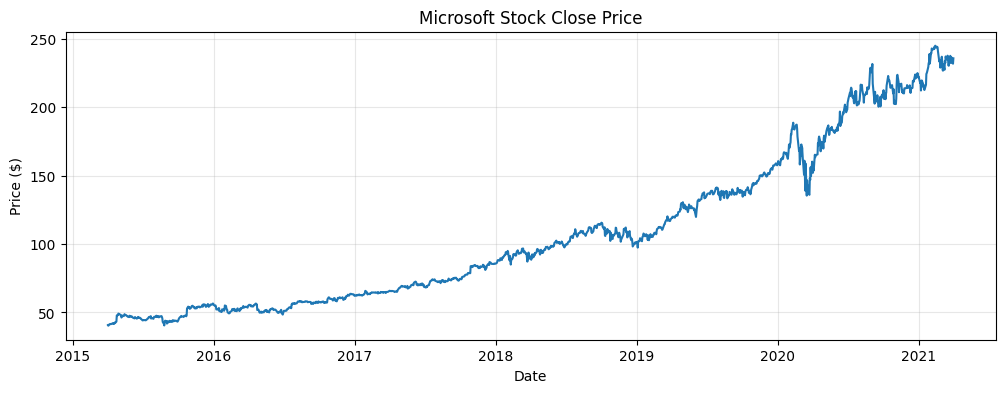

,Close Price
Date,
2015-04-01 16:00:00,40.72
2015-04-02 16:00:00,40.29
2015-04-06 16:00:00,41.55
2015-04-07 16:00:00,41.53
2015-04-08 16:00:00,41.42


In [30]:
import pandas as pd
import matplotlib.pyplot as plt

if 'Date' not in df.columns and df.index.name == 'Date':
    df = df.reset_index()

df['Date'] = pd.to_datetime(df['Date'])
df = df.set_index('Date')

ts_original = df['Close'].asfreq('D')
ts = ts_original.dropna()

removed_nans_count = ts_original.isnull().sum()
print(f"nan values removed: {removed_nans_count}")

ts.name = 'Close Price'

plt.figure(figsize=(12, 4))
plt.plot(ts, color='tab:blue')
plt.title('microsoft stock close price')
plt.xlabel('date')
plt.ylabel('price ($)')
plt.grid(alpha=0.3)
plt.show()

ts.head()

In [31]:
scaler = MinMaxScaler(feature_range=(0, 1))
ts_values = ts.values.reshape(-1, 1)
ts_scaled = scaler.fit_transform(ts_values)

print('original range:', ts_values.min(), '-', ts_values.max())
print('scaled range:', ts_scaled.min(), '-', ts_scaled.max())

Original range: 40.29 - 244.99
Scaled range: 0.0 - 0.9999999999999999


In [32]:
def create_sequences(data, window_size=12):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:i + window_size, 0])
        y.append(data[i + window_size, 0])
    return np.array(X), np.array(y)

window_size = 12
X, y = create_sequences(ts_scaled, window_size=window_size)

split_idx = int(len(X) * 0.8)
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

print(f'samples: {len(X)} | train: {X_train.shape} | test: {X_test.shape}')

Samples: 1490 | Train: (1192, 12) | Test: (298, 12)


In [33]:
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

baseline_mlp = MLPRegressor(
    hidden_layer_sizes=(64,),
    activation='relu',
    solver='adam',
    learning_rate_init=0.001,
    batch_size=16,
    max_iter=1000,
    random_state=42
)

baseline_mlp.fit(X_train, y_train)
y_train_pred = baseline_mlp.predict(X_train)
y_test_pred = baseline_mlp.predict(X_test)

## Models

In [34]:
def evaluate_regression(y_true, y_pred, scaler):
    y_true_inv = scaler.inverse_transform(y_true.reshape(-1, 1)).ravel()
    y_pred_inv = scaler.inverse_transform(y_pred.reshape(-1, 1)).ravel()

    mse = mean_squared_error(y_true_inv, y_pred_inv)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true_inv, y_pred_inv)
    return mse, rmse, mae, y_true_inv, y_pred_inv

train_mse, train_rmse, train_mae, y_train_inv, y_train_pred_inv = evaluate_regression(y_train, y_train_pred, scaler)
test_mse, test_rmse, test_mae, y_test_inv, y_test_pred_inv = evaluate_regression(y_test, y_test_pred, scaler)

print('baseline mlp')
print(f'train mse: {train_mse:.3f}, rmse: {train_rmse:.3f}, mae: {train_mae:.3f}')
print(f'test mse: {test_mse:.3f}, rmse: {test_rmse:.3f}, mae: {test_mae:.3f}')

Baseline MLP
Train | MSE: 5.514 | RMSE: 2.348 | MAE: 1.709
Test  | MSE: 159.733 | RMSE: 12.639 | MAE: 10.685


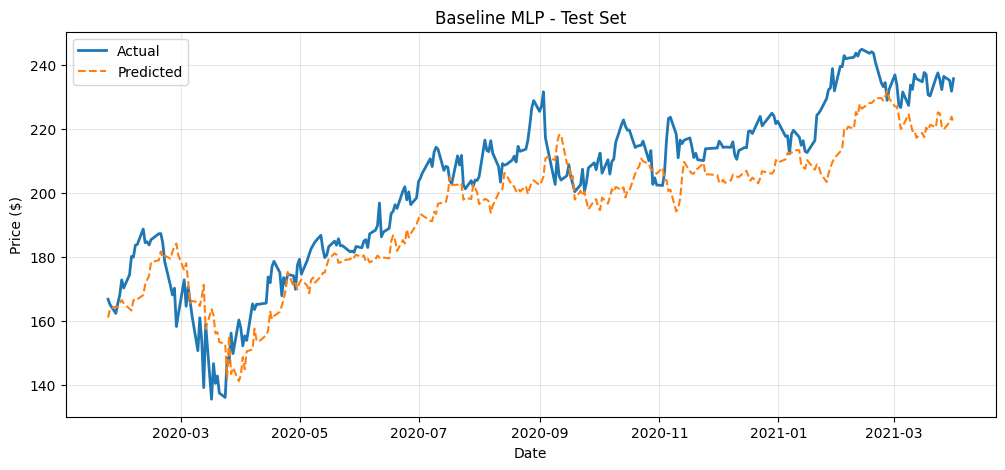

In [35]:
test_dates = ts.index[window_size + split_idx:]

plt.figure(figsize=(12, 5))
plt.plot(test_dates, y_test_inv, label='actual', linewidth=2)
plt.plot(test_dates, y_test_pred_inv, label='predicted', linestyle='--')
plt.title('baseline mlp test set')
plt.xlabel('date')
plt.ylabel('price ($)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## PART 3 - SimpleRNN Model

In [36]:
!pip install torch

In [37]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

val_ratio = 0.2
val_idx = int(len(X_train) * (1 - val_ratio))
X_tr, X_val = X_train[:val_idx], X_train[val_idx:]
y_tr, y_val = y_train[:val_idx], y_train[val_idx:]

print(f'Train: {X_tr.shape} | Validation: {X_val.shape}')

Train: (953, 12) | Validation: (239, 12)


In [38]:
def build_tf_mlp(input_dim, hidden_units=64, dropout_rate=0.1, activation='relu', learning_rate=1e-3):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(hidden_units, activation=activation),
        layers.Dropout(dropout_rate),
        layers.Dense(1)
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='mse'
    )
    return model


In [39]:
model = build_tf_mlp(
    input_dim=X_tr.shape[1],
    hidden_units=64,
    dropout_rate=0.1,
    activation='relu',
    learning_rate=0.001
)

early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True
)

history = model.fit(
    X_tr, y_tr,
    validation_data=(X_val, y_val),
    epochs=300,
    batch_size=16,
    verbose=0,
    callbacks=[early_stop]
)

print(f'best val_loss: {min(history.history["val_loss"]):.6f}')

Best val_loss: 0.000127


In [40]:
y_test_pred_best = model.predict(X_test, verbose=0).ravel()

test_mse_best, test_rmse_best, test_mae_best, y_test_inv_best, y_test_pred_inv_best = evaluate_regression(
    y_test, y_test_pred_best, scaler
)

print('tensorflow mlp')
print(f'mse: {test_mse_best:.3f}, rmse: {test_rmse_best:.3f}, mae: {test_mae_best:.3f}')

TensorFlow MLP
MSE: 49.620 | RMSE: 7.044 | MAE: 5.481


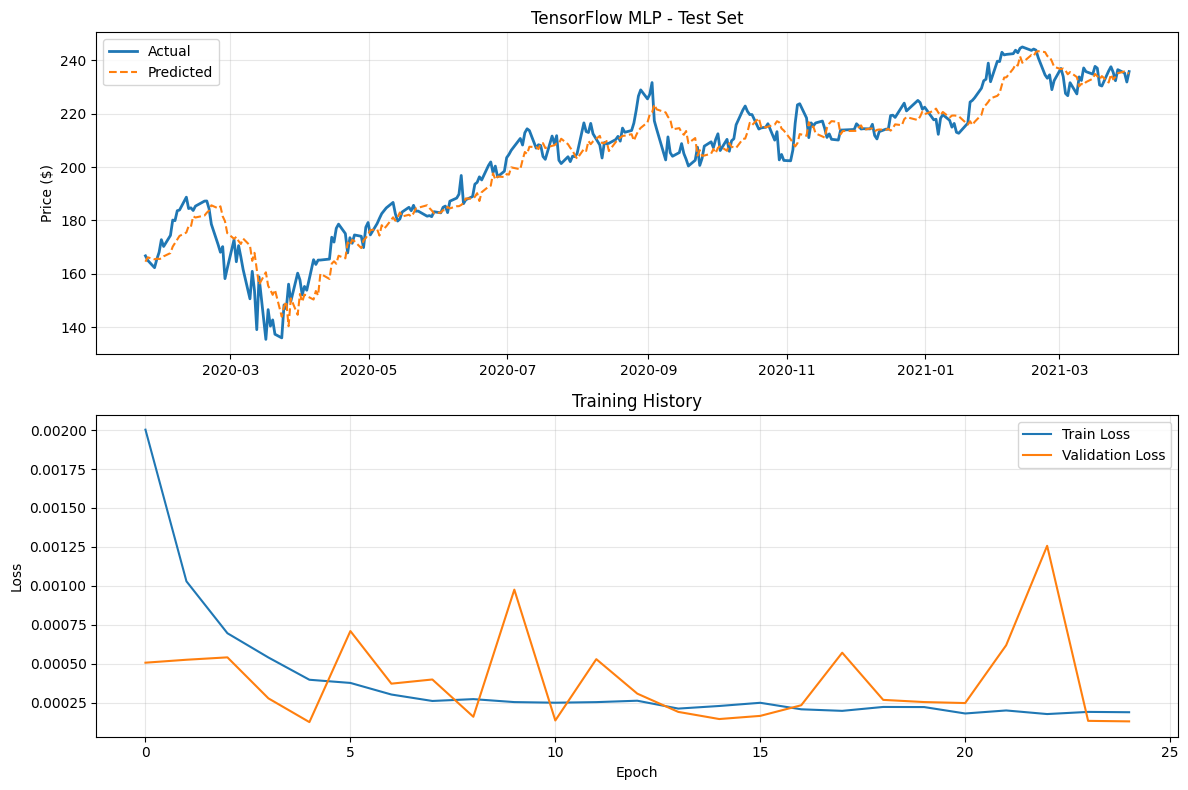

In [41]:
test_dates = ts.index[window_size + split_idx:]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

ax1.plot(test_dates, y_test_inv_best, label='actual', linewidth=2)
ax1.plot(test_dates, y_test_pred_inv_best, label='predicted', linestyle='--')
ax1.set_title('tensorflow mlp test set')
ax1.set_ylabel('price ($)')
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(history.history['loss'], label='train loss')
ax2.plot(history.history['val_loss'], label='validation loss')
ax2.set_title('training history')
ax2.set_xlabel('epoch')
ax2.set_ylabel('loss')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [42]:
X_train_rnn = X_train[..., np.newaxis]
X_test_rnn = X_test[..., np.newaxis]

val_idx = int(len(X_train_rnn) * 0.8)
X_tr, X_val = X_train_rnn[:val_idx], X_train_rnn[val_idx:]
y_tr, y_val = y_train[:val_idx], y_train[val_idx:]

print(f'rnn data shape: {X_tr.shape}')

RNN data shape: (953, 12, 1)


In [43]:
rnn_model = keras.Sequential([
    layers.Input(shape=(window_size, 1)),
    layers.SimpleRNN(32, activation='tanh'),
    layers.Dropout(0.2),
    layers.Dense(1)
])

rnn_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='mse'
)

rnn_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 32)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,121 (4.38 KB)

 Trainable params: 1,121 (4.38 KB)

 Non-trainable params: 0 (0.00 B)

In [44]:
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True
)

history_rnn = rnn_model.fit(
    X_tr, y_tr,
    validation_data=(X_val, y_val),
    epochs=300,
    batch_size=16,
    verbose=0,
    callbacks=[early_stop]
)

print(f'rnn best val_loss: {min(history_rnn.history["val_loss"]):.6f}')

RNN - Best val_loss: 0.000059


In [45]:
y_test_pred_rnn = rnn_model.predict(X_test_rnn, verbose=0).ravel()

rnn_test_mse, rnn_test_rmse, rnn_test_mae, y_test_inv_rnn, y_test_pred_inv_rnn = evaluate_regression(
    y_test, y_test_pred_rnn, scaler
)

print('simplernn')
print(f'mse: {rnn_test_mse:.3f}, rmse: {rnn_test_rmse:.3f}, mae: {rnn_test_mae:.3f}')

SimpleRNN
MSE: 31.768 | RMSE: 5.636 | MAE: 4.624


In [46]:
comparison_df = pd.DataFrame([
    {'model': 'mlp (baseline)', 'mse': test_mse, 'rmse': test_rmse, 'mae': test_mae},
    {'model': 'simplernn', 'mse': rnn_test_mse, 'rmse': rnn_test_rmse, 'mae': rnn_test_mae}
])

print('\ncomparison')
print(comparison_df)


Comparison
            Model         MSE       RMSE        MAE
0  MLP (Baseline)  159.732971  12.638551  10.685382
1       SimpleRNN   31.768312   5.636339   4.623671


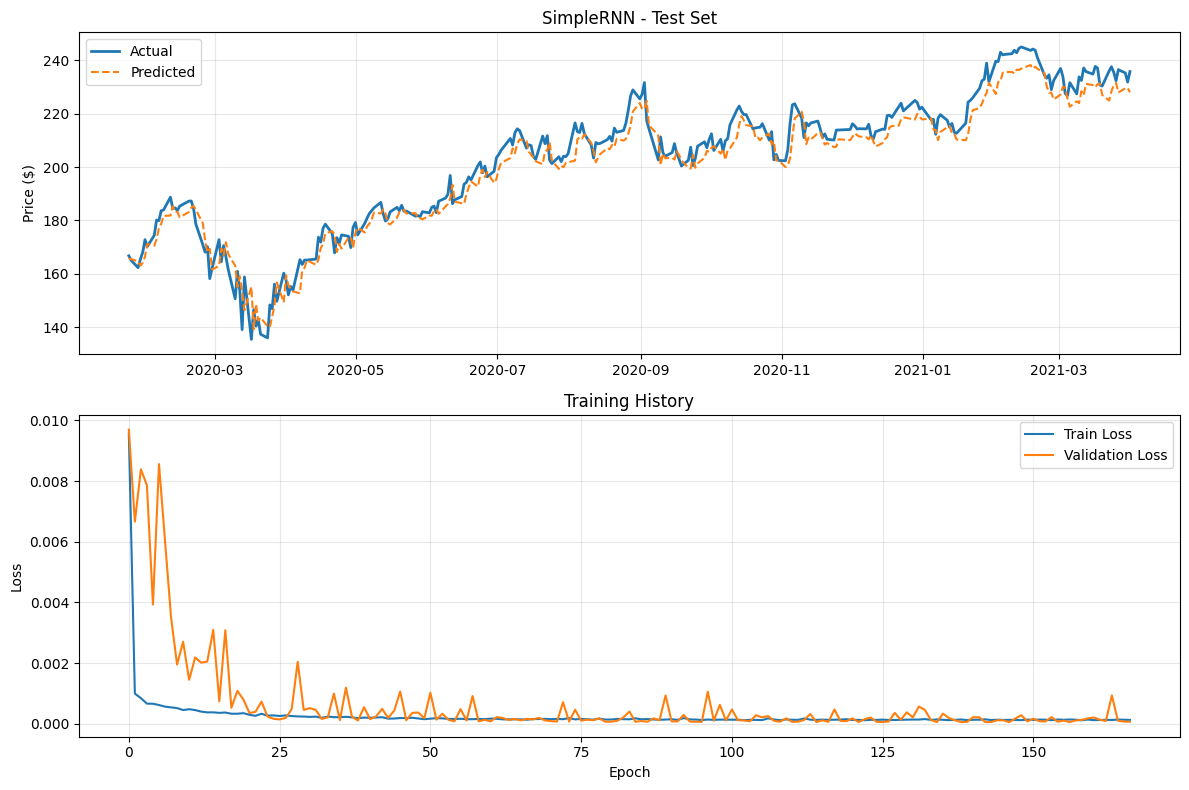

In [47]:
test_dates = ts.index[window_size + split_idx:]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

ax1.plot(test_dates, y_test_inv_rnn, label='actual', linewidth=2)
ax1.plot(test_dates, y_test_pred_inv_rnn, label='predicted', linestyle='--')
ax1.set_title('simplernn test set')
ax1.set_ylabel('price ($)')
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(history_rnn.history['loss'], label='train loss')
ax2.plot(history_rnn.history['val_loss'], label='validation loss')
ax2.set_title('training history')
ax2.set_xlabel('epoch')
ax2.set_ylabel('loss')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## PART 4 - LSTM Model

In [48]:
X_train_lstm = X_train[..., np.newaxis]
X_test_lstm = X_test[..., np.newaxis]

val_idx = int(len(X_train_lstm) * 0.8)
X_tr, X_val = X_train_lstm[:val_idx], X_train_lstm[val_idx:]
y_tr, y_val = y_train[:val_idx], y_train[val_idx:]

print(f'lstm data shape: {X_tr.shape}')

LSTM data shape: (953, 12, 1)


In [49]:
lstm_model = keras.Sequential([
    layers.Input(shape=(window_size, 1)),
    layers.LSTM(32, activation='tanh'),
    layers.Dropout(0.2),
    layers.Dense(1)
])

lstm_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='mse'
)

lstm_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 32)             │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,385 (17.13 KB)

 Trainable params: 4,385 (17.13 KB)

 Non-trainable params: 0 (0.00 B)

In [50]:
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True
)

history_lstm = lstm_model.fit(
    X_tr, y_tr,
    validation_data=(X_val, y_val),
    epochs=300,
    batch_size=16,
    verbose=0,
    callbacks=[early_stop]
)

print(f'lstm best val_loss: {min(history_lstm.history["val_loss"]):.6f}')

LSTM - Best val_loss: 0.000147


In [51]:
y_test_pred_lstm = lstm_model.predict(X_test_lstm, verbose=0).ravel()

lstm_test_mse, lstm_test_rmse, lstm_test_mae, y_test_inv_lstm, y_test_pred_inv_lstm = evaluate_regression(
    y_test, y_test_pred_lstm, scaler
)

print('lstm')
print(f'mse: {lstm_test_mse:.3f}, rmse: {lstm_test_rmse:.3f}, mae: {lstm_test_mae:.3f}')

LSTM
MSE: 108.046 | RMSE: 10.395 | MAE: 8.723


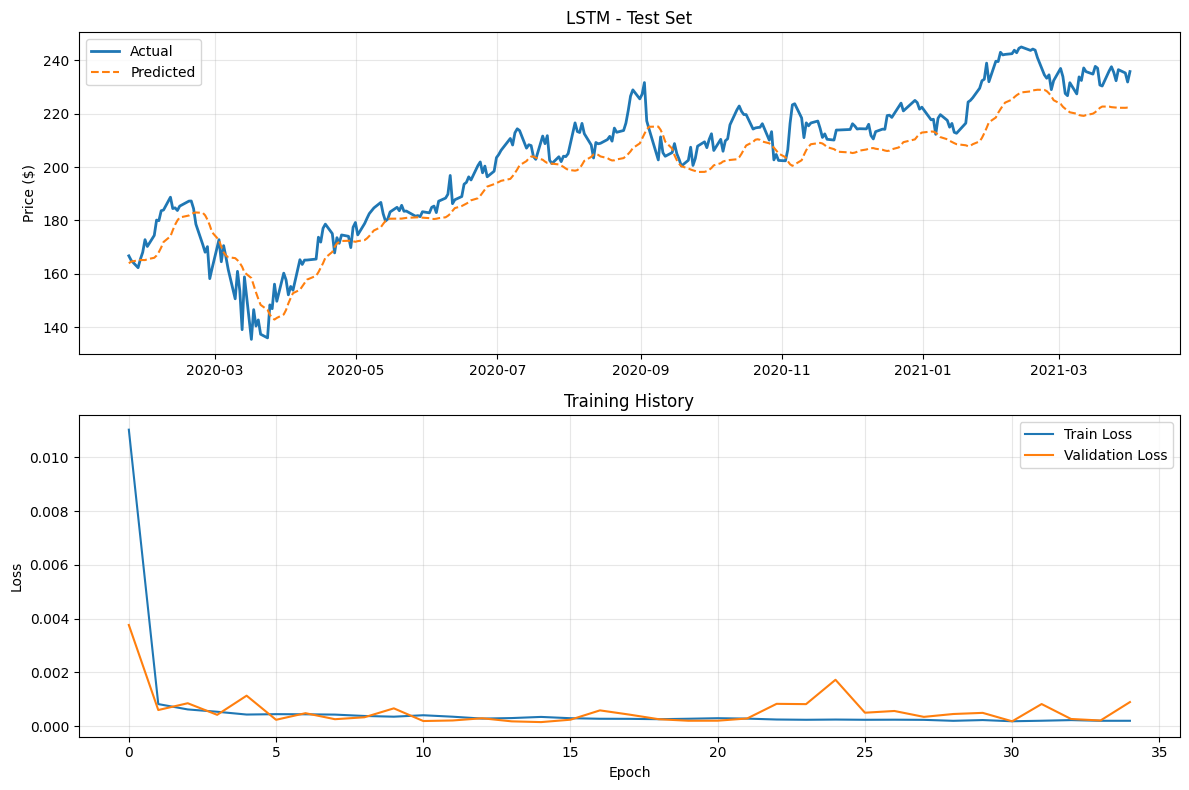

In [52]:
test_dates = ts.index[window_size + split_idx:]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

ax1.plot(test_dates, y_test_inv_lstm, label='actual', linewidth=2)
ax1.plot(test_dates, y_test_pred_inv_lstm, label='predicted', linestyle='--')
ax1.set_title('lstm test set')
ax1.set_ylabel('price ($)')
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(history_lstm.history['loss'], label='train loss')
ax2.plot(history_lstm.history['val_loss'], label='validation loss')
ax2.set_title('training history')
ax2.set_xlabel('epoch')
ax2.set_ylabel('loss')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## PART 5 - GRU Model

In [53]:
X_train_gru = X_train[..., np.newaxis]
X_test_gru = X_test[..., np.newaxis]

val_idx = int(len(X_train_gru) * 0.8)
X_tr_gru, X_val_gru = X_train_gru[:val_idx], X_train_gru[val_idx:]
y_tr_gru, y_val_gru = y_train[:val_idx], y_train[val_idx:]

gru_model = keras.Sequential([
    layers.Input(shape=(window_size, 1)),
    layers.GRU(32, activation='tanh'),
    layers.Dropout(0.2),
    layers.Dense(1)
])

gru_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='mse'
)

gru_model.summary()

early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True
)

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 32)             │         3,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,393 (13.25 KB)

 Trainable params: 3,393 (13.25 KB)

 Non-trainable params: 0 (0.00 B)

In [54]:
history_gru = gru_model.fit(
    X_tr_gru, y_tr_gru,
    validation_data=(X_val_gru, y_val_gru),
    epochs=300,
    batch_size=16,
    verbose=0,
    callbacks=[early_stop]
)

print(f'gru best val_loss: {min(history_gru.history["val_loss"]):.6f}')

GRU - Best val_loss: 0.000069


GRU
MSE: 26.671 | RMSE: 5.164 | MAE: 4.132

Comparison
            Model         MSE       RMSE        MAE
0  MLP (Baseline)  159.732971  12.638551  10.685382
1       SimpleRNN   31.768312   5.636339   4.623671
2             GRU   26.670820   5.164380   4.132085


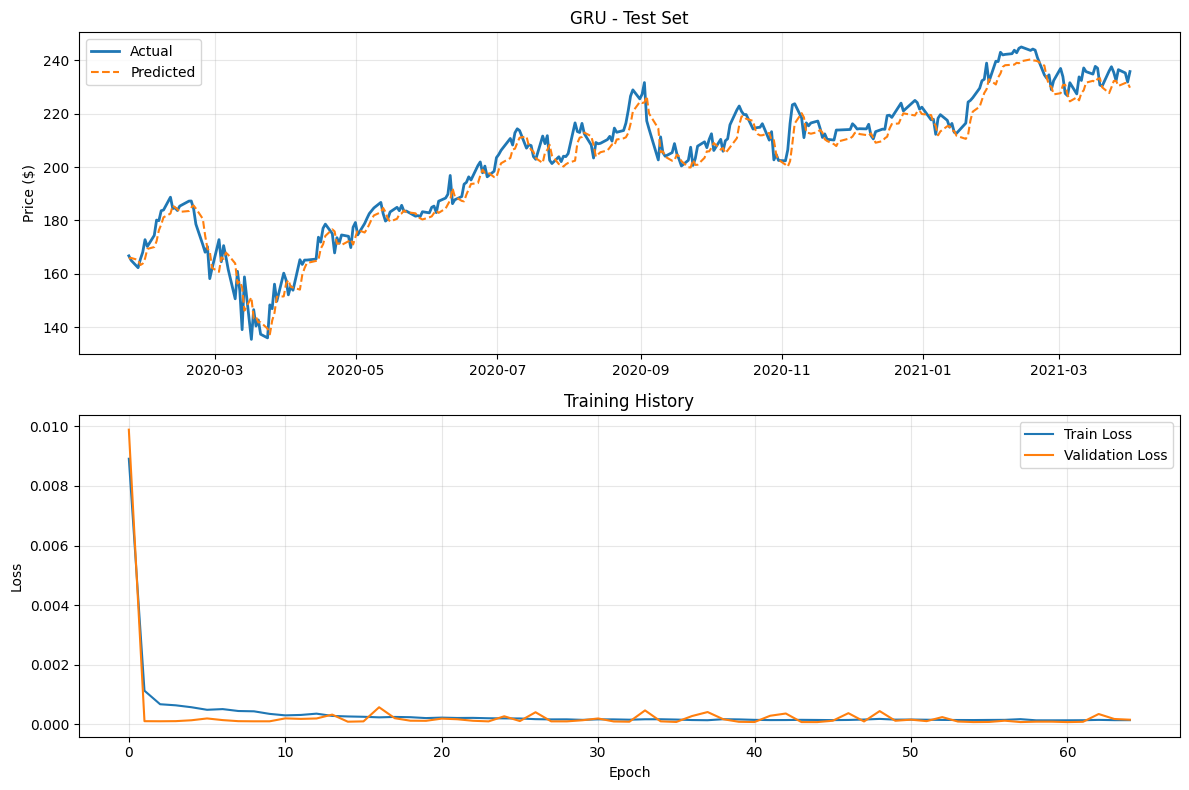

In [55]:
y_test_pred_gru = gru_model.predict(X_test_gru, verbose=0).ravel()

gru_test_mse, gru_test_rmse, gru_test_mae, y_test_inv_gru, y_test_pred_inv_gru = evaluate_regression(
    y_test, y_test_pred_gru, scaler
)

print('gru')
print(f'mse: {gru_test_mse:.3f}, rmse: {gru_test_rmse:.3f}, mae: {gru_test_mae:.3f}')

comparison_df = pd.concat([
    comparison_df,
    pd.DataFrame([{'model': 'gru', 'mse': gru_test_mse, 'rmse': gru_test_rmse, 'mae': gru_test_mae}])
], ignore_index=True)

print('\ncomparison')
print(comparison_df)

test_dates = ts.index[window_size + split_idx:]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

ax1.plot(test_dates, y_test_inv_gru, label='actual', linewidth=2)
ax1.plot(test_dates, y_test_pred_inv_gru, label='predicted', linestyle='--')
ax1.set_title('gru test set')
ax1.set_ylabel('price ($)')
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(history_gru.history['loss'], label='train loss')
ax2.plot(history_gru.history['val_loss'], label='validation loss')
ax2.set_title('training history')
ax2.set_xlabel('epoch')
ax2.set_ylabel('loss')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

---

# PART 6 - Conv1D Model

In [56]:
X_train_cnn = X_train_gru
X_test_cnn = X_test_gru

val_idx = int(len(X_train_cnn) * 0.8)
X_tr_cnn, X_val_cnn = X_train_cnn[:val_idx], X_train_cnn[val_idx:]
y_tr_cnn, y_val_cnn = y_train[:val_idx], y_train[val_idx:]

conv1d_model = keras.Sequential([
    layers.Input(shape=(window_size, 1)),
    layers.Conv1D(filters=32, kernel_size=3, activation='relu'),
    layers.MaxPooling1D(pool_size=2),
    layers.Flatten(),
    layers.Dropout(0.2),
    layers.Dense(1)
])

conv1d_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='mse'
)

conv1d_model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 10, 32)         │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 5, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 160)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 160)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           161 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 289 (1.13 KB)

 Trainable params: 289 (1.13 KB)

 Non-trainable params: 0 (0.00 B)

In [57]:
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True
)

history_conv1d = conv1d_model.fit(
    X_tr_cnn, y_tr_cnn,
    validation_data=(X_val_cnn, y_val_cnn),
    epochs=300,
    batch_size=16,
    verbose=0,
    callbacks=[early_stop]
)

print(f'conv1d best val_loss: {min(history_conv1d.history["val_loss"]):.6f}')

Conv1D - Best val_loss: 0.000155


In [58]:
y_test_pred_conv1d = conv1d_model.predict(X_test_cnn, verbose=0).ravel()

conv1d_test_mse, conv1d_test_rmse, conv1d_test_mae, y_test_inv_conv1d, y_test_pred_inv_conv1d = evaluate_regression(
    y_test, y_test_pred_conv1d, scaler
)

print('conv1d')
print(f'mse: {conv1d_test_mse:.3f}, rmse: {conv1d_test_rmse:.3f}, mae: {conv1d_test_mae:.3f}')

comparison_df = pd.concat([
    comparison_df,
    pd.DataFrame([{'model': 'conv1d', 'mse': conv1d_test_mse, 'rmse': conv1d_test_rmse, 'mae': conv1d_test_mae}])
], ignore_index=True)

print('\ncomparison')
print(comparison_df)

Conv1D
MSE: 58.227 | RMSE: 7.631 | MAE: 5.773

Comparison
            Model         MSE       RMSE        MAE
0  MLP (Baseline)  159.732971  12.638551  10.685382
1       SimpleRNN   31.768312   5.636339   4.623671
2             GRU   26.670820   5.164380   4.132085
3          Conv1D   58.227385   7.630687   5.773037


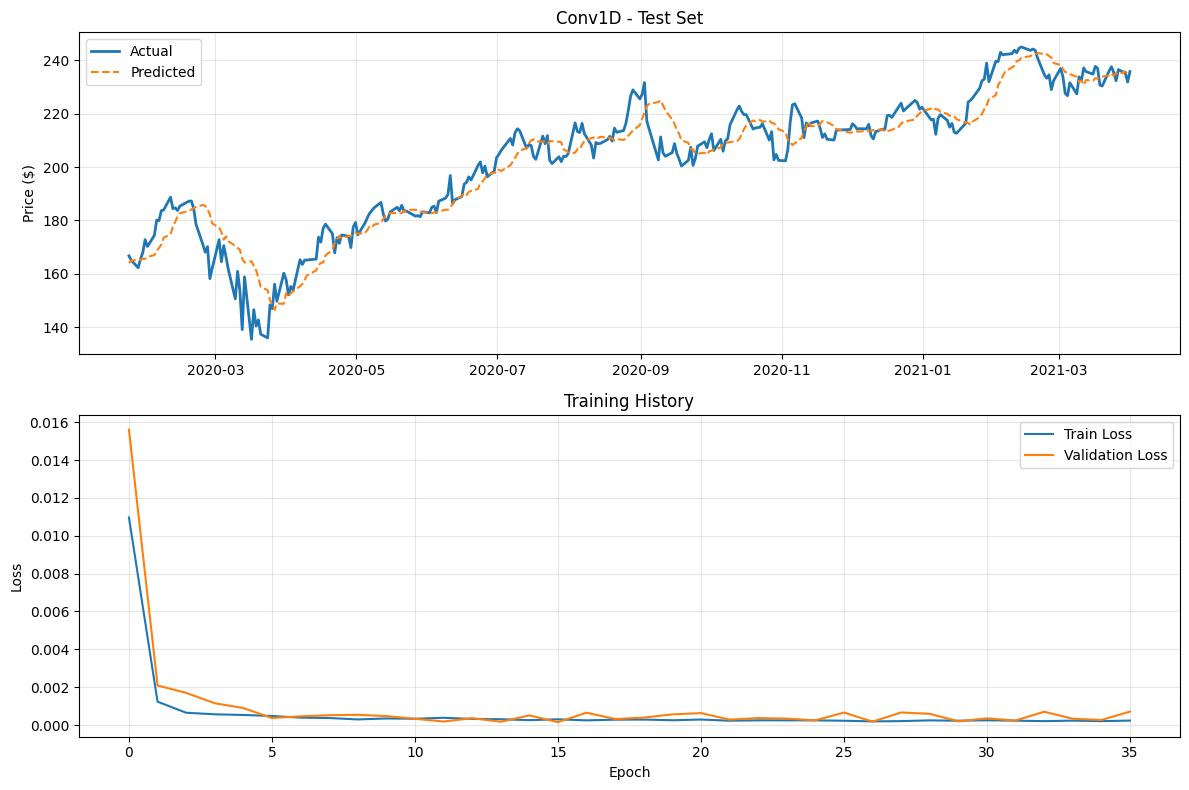

In [59]:
test_dates = ts.index[window_size + split_idx:]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

ax1.plot(test_dates, y_test_inv_conv1d, label='actual', linewidth=2)
ax1.plot(test_dates, y_test_pred_inv_conv1d, label='predicted', linestyle='--')
ax1.set_title('conv1d test set')
ax1.set_ylabel('price ($)')
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(history_conv1d.history['loss'], label='train loss')
ax2.plot(history_conv1d.history['val_loss'], label='validation loss')
ax2.set_title('training history')
ax2.set_xlabel('epoch')
ax2.set_ylabel('loss')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## PART 7 - CNN-LSTM Model

In [60]:
X_train_cnnlstm = X_train_gru
X_test_cnnlstm = X_test_gru

val_idx = int(len(X_train_cnnlstm) * 0.8)
X_tr_cnnlstm, X_val_cnnlstm = X_train_cnnlstm[:val_idx], X_train_cnnlstm[val_idx:]
y_tr_cnnlstm, y_val_cnnlstm = y_train[:val_idx], y_train[val_idx:]

cnnlstm_model = keras.Sequential([
    layers.Input(shape=(window_size, 1)),
    layers.Conv1D(filters=64, kernel_size=3, activation='relu', padding='causal'),
    layers.MaxPooling1D(pool_size=2),
    layers.LSTM(64, activation='tanh', recurrent_dropout=0.2),
    layers.Dropout(0.3),
    layers.Dense(1)
])

cnnlstm_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='mse'
)

cnnlstm_model.summary()

early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True
)

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_1 (Conv1D)               │ (None, 12, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 6, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,345 (130.25 KB)

 Trainable params: 33,345 (130.25 KB)

 Non-trainable params: 0 (0.00 B)

In [61]:
history_cnnlstm = cnnlstm_model.fit(
    X_tr_cnnlstm, y_tr_cnnlstm,
    validation_data=(X_val_cnnlstm, y_val_cnnlstm),
    epochs=300,
    batch_size=16,
    verbose=0,
    callbacks=[early_stop]
)

print(f'cnn-lstm best val_loss: {min(history_cnnlstm.history["val_loss"]):.6f}')

CNN-LSTM - Best val_loss: 0.000145


CNN-LSTM
MSE: 60.939 | RMSE: 7.806 | MAE: 5.845

Comparison
            Model         MSE       RMSE        MAE
0  MLP (Baseline)  159.732971  12.638551  10.685382
1       SimpleRNN   31.768312   5.636339   4.623671
2             GRU   26.670820   5.164380   4.132085
3          Conv1D   58.227385   7.630687   5.773037
4        CNN-LSTM   60.938596   7.806318   5.845407


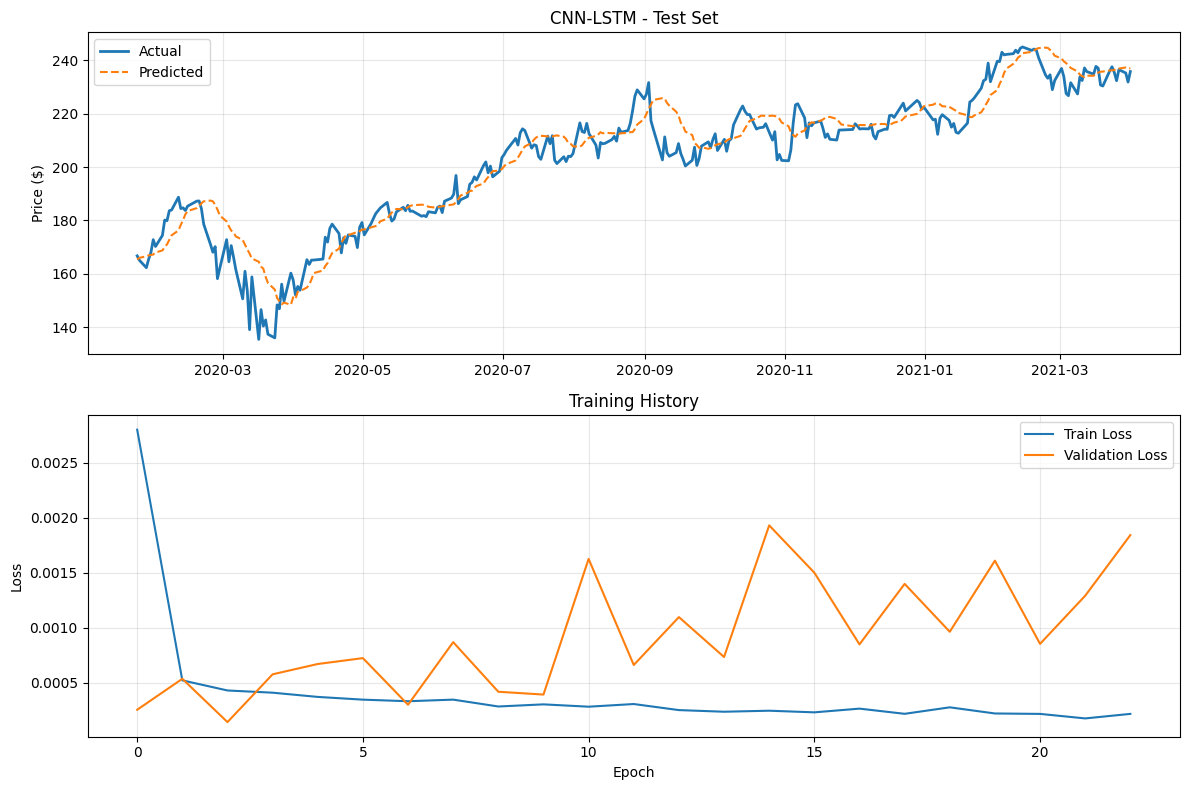

In [62]:
y_test_pred_cnnlstm = cnnlstm_model.predict(X_test_cnnlstm, verbose=0).ravel()

cnnlstm_test_mse, cnnlstm_test_rmse, cnnlstm_test_mae, y_test_inv_cnnlstm, y_test_pred_inv_cnnlstm = evaluate_regression(
    y_test, y_test_pred_cnnlstm, scaler
)

print('cnn-lstm')
print(f'mse: {cnnlstm_test_mse:.3f}, rmse: {cnnlstm_test_rmse:.3f}, mae: {cnnlstm_test_mae:.3f}')

comparison_df = pd.concat([
    comparison_df,
    pd.DataFrame([{'model': 'cnn-lstm', 'mse': cnnlstm_test_mse, 'rmse': cnnlstm_test_rmse, 'mae': cnnlstm_test_mae}])
], ignore_index=True)

print('\ncomparison')
print(comparison_df)

test_dates = ts.index[window_size + split_idx:]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

ax1.plot(test_dates, y_test_inv_cnnlstm, label='actual', linewidth=2)
ax1.plot(test_dates, y_test_pred_inv_cnnlstm, label='predicted', linestyle='--')
ax1.set_title('cnn-lstm test set')
ax1.set_ylabel('price ($)')
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(history_cnnlstm.history['loss'], label='train loss')
ax2.plot(history_cnnlstm.history['val_loss'], label='validation loss')
ax2.set_title('training history')
ax2.set_xlabel('epoch')
ax2.set_ylabel('loss')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## PART 8 - LSTM + Attention Model

In [63]:
X_train_attn = X_train[..., np.newaxis]
X_test_attn = X_test[..., np.newaxis]

val_idx = int(len(X_train_attn) * 0.8)
X_tr_attn, X_val_attn = X_train_attn[:val_idx], X_train_attn[val_idx:]
y_tr_attn, y_val_attn = y_train[:val_idx], y_train[val_idx:]

lstm_units = 64

inputs = keras.Input(shape=(window_size, 1))
lstm_out = layers.LSTM(lstm_units, activation='tanh', recurrent_dropout=0.2, return_sequences=True)(inputs)
dropout_lstm = layers.Dropout(0.3)(lstm_out)

query_vec = layers.Dense(lstm_units, activation='tanh')(dropout_lstm)
attention_output = layers.AdditiveAttention()([query_vec, dropout_lstm])

attention_dim = 10
energy = layers.Dense(attention_dim, activation='tanh')(dropout_lstm)
scores = layers.Dense(1)(energy)
attention_weights = layers.Softmax(axis=1)(scores)

context_vector = layers.Multiply()([attention_weights, dropout_lstm])
context_vector = layers.Lambda(lambda x: tf.reduce_sum(x, axis=1))(context_vector)

outputs = layers.Dense(1)(context_vector)

lstm_attn_model = keras.Model(inputs=inputs, outputs=outputs)
lstm_attn_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='mse'
)

lstm_attn_model.summary()

early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True
)

Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6       │ (None, 12, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_2 (LSTM)       │ (None, 12, 64)    │     16,896 │ input_layer_6[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_6 (Dropout) │ (None, 12, 64)    │          0 │ lstm_2[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 12, 10)    │        650 │ dropout_6[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 12, 1)     │         11 │ dense_8[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ softmax (Softmax)   │ (None, 12, 1)     │          0 │ dense_9[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 12, 64)    │          0 │ softmax[0][0],    │
│                     │                   │            │ dropout_6[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 64)        │          0 │ multiply[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 1)         │         65 │ lambda[0][0]      │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 17,622 (68.84 KB)

 Trainable params: 17,622 (68.84 KB)

 Non-trainable params: 0 (0.00 B)

In [64]:
history_lstm_attn = lstm_attn_model.fit(
    X_tr_attn, y_tr_attn,
    validation_data=(X_val_attn, y_val_attn),
    epochs=300,
    batch_size=16,
    verbose=0,
    callbacks=[early_stop]
)

print(f'lstm + attention best val_loss: {min(history_lstm_attn.history["val_loss"]):.6f}')

LSTM + Attention - Best val_loss: 0.000186


LSTM + Attention
MSE: 112.073 | RMSE: 10.586 | MAE: 8.795

Comparison
              Model         MSE       RMSE        MAE
0    MLP (Baseline)  159.732971  12.638551  10.685382
1         SimpleRNN   31.768312   5.636339   4.623671
2               GRU   26.670820   5.164380   4.132085
3            Conv1D   58.227385   7.630687   5.773037
4          CNN-LSTM   60.938596   7.806318   5.845407
5  LSTM + Attention  112.073392  10.586472   8.795390


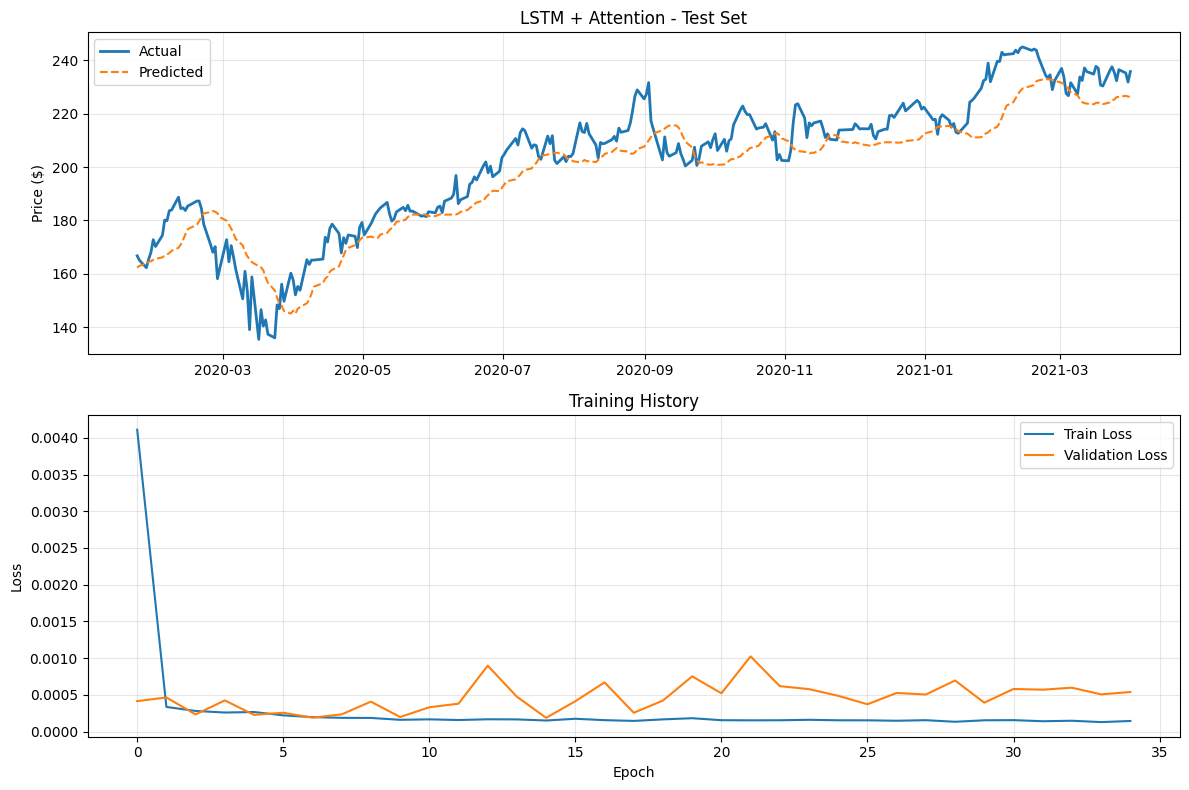

In [65]:
y_test_pred_lstm_attn = lstm_attn_model.predict(X_test_attn, verbose=0).ravel()

lstm_attn_test_mse, lstm_attn_test_rmse, lstm_attn_test_mae, y_test_inv_lstm_attn, y_test_pred_inv_lstm_attn = evaluate_regression(
    y_test, y_test_pred_lstm_attn, scaler
)

print('lstm + attention')
print(f'mse: {lstm_attn_test_mse:.3f}, rmse: {lstm_attn_test_rmse:.3f}, mae: {lstm_attn_test_mae:.3f}')

comparison_df = pd.concat([
    comparison_df,
    pd.DataFrame([{'model': 'lstm + attention', 'mse': lstm_attn_test_mse, 'rmse': lstm_attn_test_rmse, 'mae': lstm_attn_test_mae}])
], ignore_index=True)

print('\ncomparison')
print(comparison_df)

test_dates = ts.index[window_size + split_idx:]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

ax1.plot(test_dates, y_test_inv_lstm_attn, label='actual', linewidth=2)
ax1.plot(test_dates, y_test_pred_inv_lstm_attn, label='predicted', linestyle='--')
ax1.set_title('lstm + attention test set')
ax1.set_ylabel('price ($)')
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(history_lstm_attn.history['loss'], label='train loss')
ax2.plot(history_lstm_attn.history['val_loss'], label='validation loss')
ax2.set_title('training history')
ax2.set_xlabel('epoch')
ax2.set_ylabel('loss')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

---

# PART 9 - Transformer Model

In [66]:
X_train_tf = X_train[..., np.newaxis]
X_test_tf = X_test[..., np.newaxis]

val_idx = int(len(X_train_tf) * 0.8)
X_tr_tf, X_val_tf = X_train_tf[:val_idx], X_train_tf[val_idx:]
y_tr_tf, y_val_tf = y_train[:val_idx], y_train[val_idx:]

print(f'transformer data shape: {X_tr_tf.shape}')

Transformer data shape: (953, 12, 1)


In [67]:
class PositionalEncoding(layers.Layer):
    def __init__(self, position, d_model, **kwargs):
        super(PositionalEncoding, self).__init__(**kwargs)
        self.position = position
        self.d_model = d_model
        self.pos_encoding = self.positional_encoding(position, d_model)

    def get_angles(self, position, i, d_model):
        angles = 1 / np.power(10000, (2 * (i // 2)) / np.float32(d_model))
        return position * angles

    def positional_encoding(self, position, d_model):
        angle_rads = self.get_angles(np.arange(position)[:, np.newaxis],
                                     np.arange(d_model)[np.newaxis, :],
                                     d_model)

        # apply sin to even indices in the array; 2i
        angle_rads[:, 0::2] = np.sin(angle_rads[:, 0::2])

        # apply cos to odd indices in the array; 2i + 1
        angle_rads[:, 1::2] = np.cos(angle_rads[:, 1::2])

        pos_encoding = tf.cast(angle_rads[np.newaxis, ...], dtype=tf.float32)
        return pos_encoding

    def call(self, inputs):
        return inputs + self.pos_encoding[:, :tf.shape(inputs)[1], :]

In [68]:
def scaled_dot_product_attention(query, key, value, mask):
    matmul_qk = tf.matmul(query, key, transpose_b=True)
    dk = tf.cast(tf.shape(key)[-1], tf.float32)
    scaled_attention_logits = matmul_qk / tf.math.sqrt(dk)

    if mask is not None:
        scaled_attention_logits += (mask * -1e9)

    attention_weights = tf.nn.softmax(scaled_attention_logits, axis=-1)
    output = tf.matmul(attention_weights, value)
    return output, attention_weights

class MultiHeadSelfAttention(layers.Layer):
    def __init__(self, d_model, num_heads, **kwargs):
        super(MultiHeadSelfAttention, self).__init__(**kwargs)
        self.num_heads = num_heads
        self.d_model = d_model

        assert d_model % self.num_heads == 0

        self.depth = d_model // self.num_heads

        self.wq = layers.Dense(d_model)
        self.wk = layers.Dense(d_model)
        self.wv = layers.Dense(d_model)

        self.dense = layers.Dense(d_model)

    def split_heads(self, x, batch_size):
        x = tf.reshape(x, (batch_size, -1, self.num_heads, self.depth))
        return tf.transpose(x, perm=[0, 2, 1, 3])

    def call(self, v, k, q, mask=None):
        batch_size = tf.shape(q)[0]

        q = self.wq(q)  # (batch_size, seq_len, d_model)
        k = self.wk(k)  # (batch_size, seq_len, d_model)
        v = self.wv(v)  # (batch_size, seq_len, d_model)

        q = self.split_heads(q, batch_size)  # (batch_size, num_heads, seq_len_q, depth)
        k = self.split_heads(k, batch_size)  # (batch_size, num_heads, seq_len_k, depth)
        v = self.split_heads(v, batch_size)  # (batch_size, num_heads, seq_len_v, depth)

        scaled_attention, attention_weights = scaled_dot_product_attention(
            q, k, v, mask)

        scaled_attention = tf.transpose(scaled_attention, perm=[0, 2, 1, 3])  # (batch_size, seq_len_q, num_heads, depth)

        concat_attention = tf.reshape(scaled_attention,
                                      (batch_size, -1, self.d_model))  # (batch_size, seq_len_q, d_model)

        output = self.dense(concat_attention)  # (batch_size, seq_len_q, d_model)
        return output, attention_weights

### 3. Feed Forward Network and Transformer Block

In [69]:
def point_wise_feed_forward_network(d_model, dff):
    return keras.Sequential([
        layers.Dense(dff, activation='relu'),  # (batch_size, seq_len, dff)
        layers.Dense(d_model)  # (batch_size, seq_len, d_model)
    ])

class TransformerBlock(layers.Layer):
    def __init__(self, d_model, num_heads, dff, rate=0.1, **kwargs):
        super(TransformerBlock, self).__init__(**kwargs)
        self.mha = MultiHeadSelfAttention(d_model, num_heads)
        self.ffn = point_wise_feed_forward_network(d_model, dff)

        self.layernorm1 = layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = layers.LayerNormalization(epsilon=1e-6)

        self.dropout1 = layers.Dropout(rate)
        self.dropout2 = layers.Dropout(rate)

    def call(self, x, training, mask=None):
        attn_output, _ = self.mha(x, x, x, mask)  # (batch_size, input_seq_len, d_model)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(x + attn_output)

        ffn_output = self.ffn(out1)  # (batch_size, input_seq_len, d_model)
        ffn_output = self.dropout2(ffn_output, training=training)
        out2 = self.layernorm2(out1 + ffn_output)

        return out2

### 4. Transformer Model for Time Series

In [70]:
class TimeSeriesTransformer(keras.Model):
    def __init__(self, num_layers, d_model, num_heads, dff, input_seq_len, rate=0.1, **kwargs):
        super(TimeSeriesTransformer, self).__init__(**kwargs)
        self.d_model = d_model
        self.input_seq_len = input_seq_len

        self.embedding = layers.Dense(d_model) # Project input features to d_model
        self.pos_encoding = PositionalEncoding(input_seq_len, d_model)

        self.enc_layers = [TransformerBlock(d_model, num_heads, dff, rate) for _ in range(num_layers)]

        self.final_layer = layers.Dense(1)

    def call(self, inputs, training=False, mask=None):
        seq_len = tf.shape(inputs)[1]

        # Assuming input is (batch, sequence_length, 1) and we need to project it to d_model
        x = self.embedding(inputs)  # (batch_size, input_seq_len, d_model)
        x *= tf.math.sqrt(tf.cast(self.d_model, tf.float32))
        x = self.pos_encoding(x)

        for i in range(len(self.enc_layers)):
            x = self.enc_layers[i](x, training=training, mask=mask)

        # For time series forecasting, we typically want a single prediction output.
        # One common approach is to take the output of the last timestep of the Transformer encoder.
        # Or, pool the output, or use a dense layer on the last encoder output.
        # Here, we'll flatten the output and then use a dense layer.

        # Option 1: Take the output of the last timestep
        # x = x[:, -1, :]

        # Option 2: Flatten and then dense
        x = layers.Flatten()(x)

        output = self.final_layer(x)  # (batch_size, 1)

        return output

In [71]:
num_layers = 2
d_model = 64
num_heads = 4
dff = 128
rate = 0.1

transformer_model = TimeSeriesTransformer(
    num_layers=num_layers,
    d_model=d_model,
    num_heads=num_heads,
    dff=dff,
    input_seq_len=window_size,
    rate=rate
)

transformer_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='mse'
)

transformer_model.build(input_shape=X_tr_tf.shape)
transformer_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:424: UserWarning: `build()` was called on layer 'time_series_transformer', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


Model: "time_series_transformer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_11 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ positional_encoding             │ ?                      │   0 (unbuilt) │
│ (PositionalEncoding)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block               │ ?                      │   0 (unbuilt) │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_1             │ ?                      │   0 (unbuilt) │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [72]:
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True
)

history_transformer = transformer_model.fit(
    X_tr_tf, y_tr_tf,
    validation_data=(X_val_tf, y_val_tf),
    epochs=300,
    batch_size=16,
    verbose=0,
    callbacks=[early_stop]
)

print(f'transformer best val_loss: {min(history_transformer.history["val_loss"]):.6f}')

Transformer - Best val_loss: 0.001406


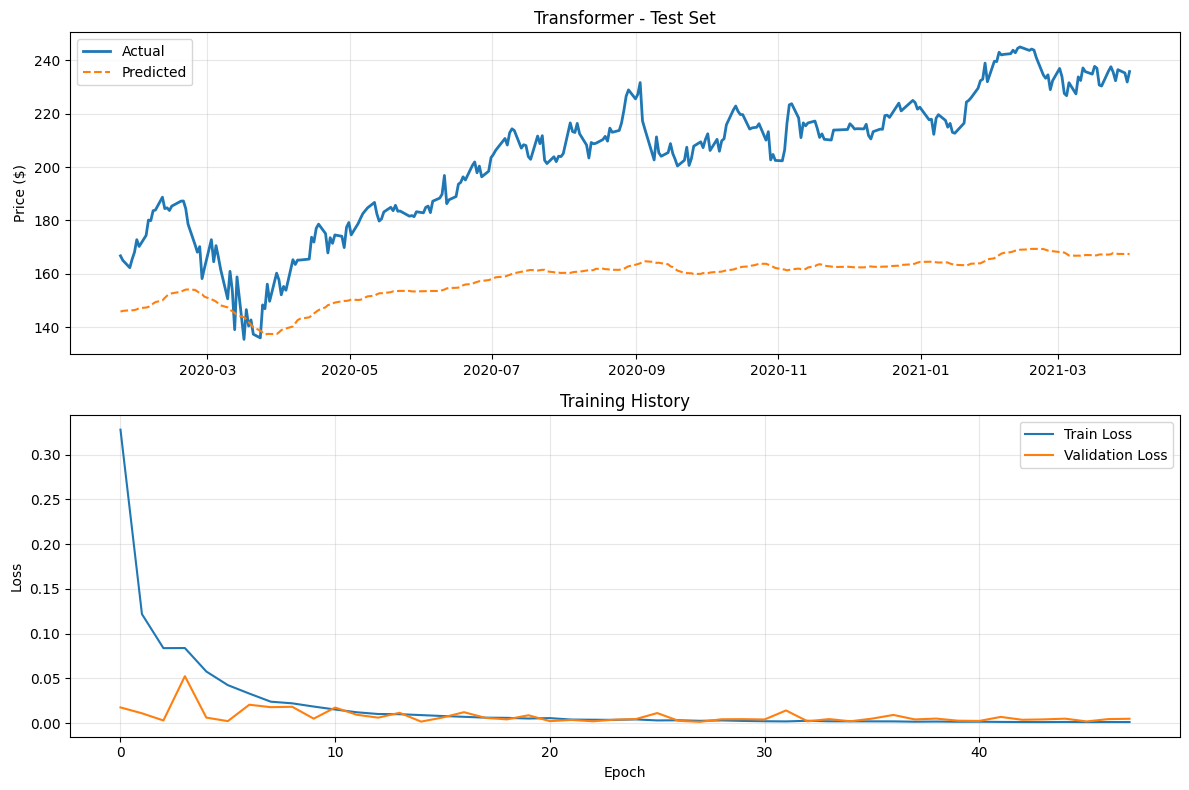

In [76]:
test_dates = ts.index[window_size + split_idx:]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

ax1.plot(test_dates, y_test_inv_transformer, label='actual', linewidth=2)
ax1.plot(test_dates, y_test_pred_inv_transformer, label='predicted', linestyle='--')
ax1.set_title('transformer test set')
ax1.set_ylabel('price ($)')
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(history_transformer.history['loss'], label='train loss')
ax2.plot(history_transformer.history['val_loss'], label='validation loss')
ax2.set_title('training history')
ax2.set_xlabel('epoch')
ax2.set_ylabel('loss')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [73]:
y_test_pred_transformer = transformer_model.predict(X_test_tf, verbose=0).ravel()

transformer_test_mse, transformer_test_rmse, transformer_test_mae, y_test_inv_transformer, y_test_pred_inv_transformer = evaluate_regression(
    y_test, y_test_pred_transformer, scaler
)

print('transformer')
print(f'mse: {transformer_test_mse:.3f}, rmse: {transformer_test_rmse:.3f}, mae: {transformer_test_mae:.3f}')

comparison_df = pd.concat([
    comparison_df,
    pd.DataFrame([{'model': 'transformer', 'mse': transformer_test_mse, 'rmse': transformer_test_rmse, 'mae': transformer_test_mae}])
], ignore_index=True)

print('\ncomparison')
print(comparison_df)

Transformer
MSE: 2267.645 | RMSE: 47.620 | MAE: 44.258

Comparison
              Model          MSE       RMSE        MAE
0    MLP (Baseline)   159.732971  12.638551  10.685382
1         SimpleRNN    31.768312   5.636339   4.623671
2               GRU    26.670820   5.164380   4.132085
3            Conv1D    58.227385   7.630687   5.773037
4          CNN-LSTM    60.938596   7.806318   5.845407
5  LSTM + Attention   112.073392  10.586472   8.795390
6       Transformer  2267.645138  47.619798  44.257906


## Final Model Comparison

In [84]:
model_results = [
    {'model': 'tensorflow mlp', 'mse': test_mse_best, 'rmse': test_rmse_best, 'mae': test_mae_best, 'predictions': y_test_pred_inv_best},
    {'model': 'simplernn', 'mse': rnn_test_mse, 'rmse': rnn_test_rmse, 'mae': rnn_test_mae, 'predictions': y_test_pred_inv_rnn},
    {'model': 'lstm', 'mse': lstm_test_mse, 'rmse': lstm_test_rmse, 'mae': lstm_test_mae, 'predictions': y_test_pred_inv_lstm},
    {'model': 'gru', 'mse': gru_test_mse, 'rmse': gru_test_rmse, 'mae': gru_test_mae, 'predictions': y_test_pred_inv_gru},
    {'model': 'conv1d', 'mse': conv1d_test_mse, 'rmse': conv1d_test_rmse, 'mae': conv1d_test_mae, 'predictions': y_test_pred_inv_conv1d},
    {'model': 'cnn-lstm', 'mse': cnnlstm_test_mse, 'rmse': cnnlstm_test_rmse, 'mae': cnnlstm_test_mae, 'predictions': y_test_pred_inv_cnnlstm},
    {'model': 'lstm + attention', 'mse': lstm_attn_test_mse, 'rmse': lstm_attn_test_rmse, 'mae': lstm_attn_test_mae, 'predictions': y_test_pred_inv_lstm_attn},
    {'model': 'transformer', 'mse': transformer_test_mse, 'rmse': transformer_test_rmse, 'mae': transformer_test_mae, 'predictions': y_test_pred_inv_transformer}
]

comparison_df_plot = pd.DataFrame(model_results)

print('final results')
print(comparison_df_plot.drop(columns=['predictions']))

final results
              model          mse       rmse        mae
0    tensorflow mlp    49.620190   7.044160   5.481302
1         simplernn    31.768312   5.636339   4.623671
2              lstm   108.045893  10.394513   8.723269
3               gru    26.670820   5.164380   4.132085
4            conv1d    58.227385   7.630687   5.773037
5          cnn-lstm    60.938596   7.806318   5.845407
6  lstm + attention   112.073392  10.586472   8.795390
7       transformer  2267.645138  47.619798  44.257906


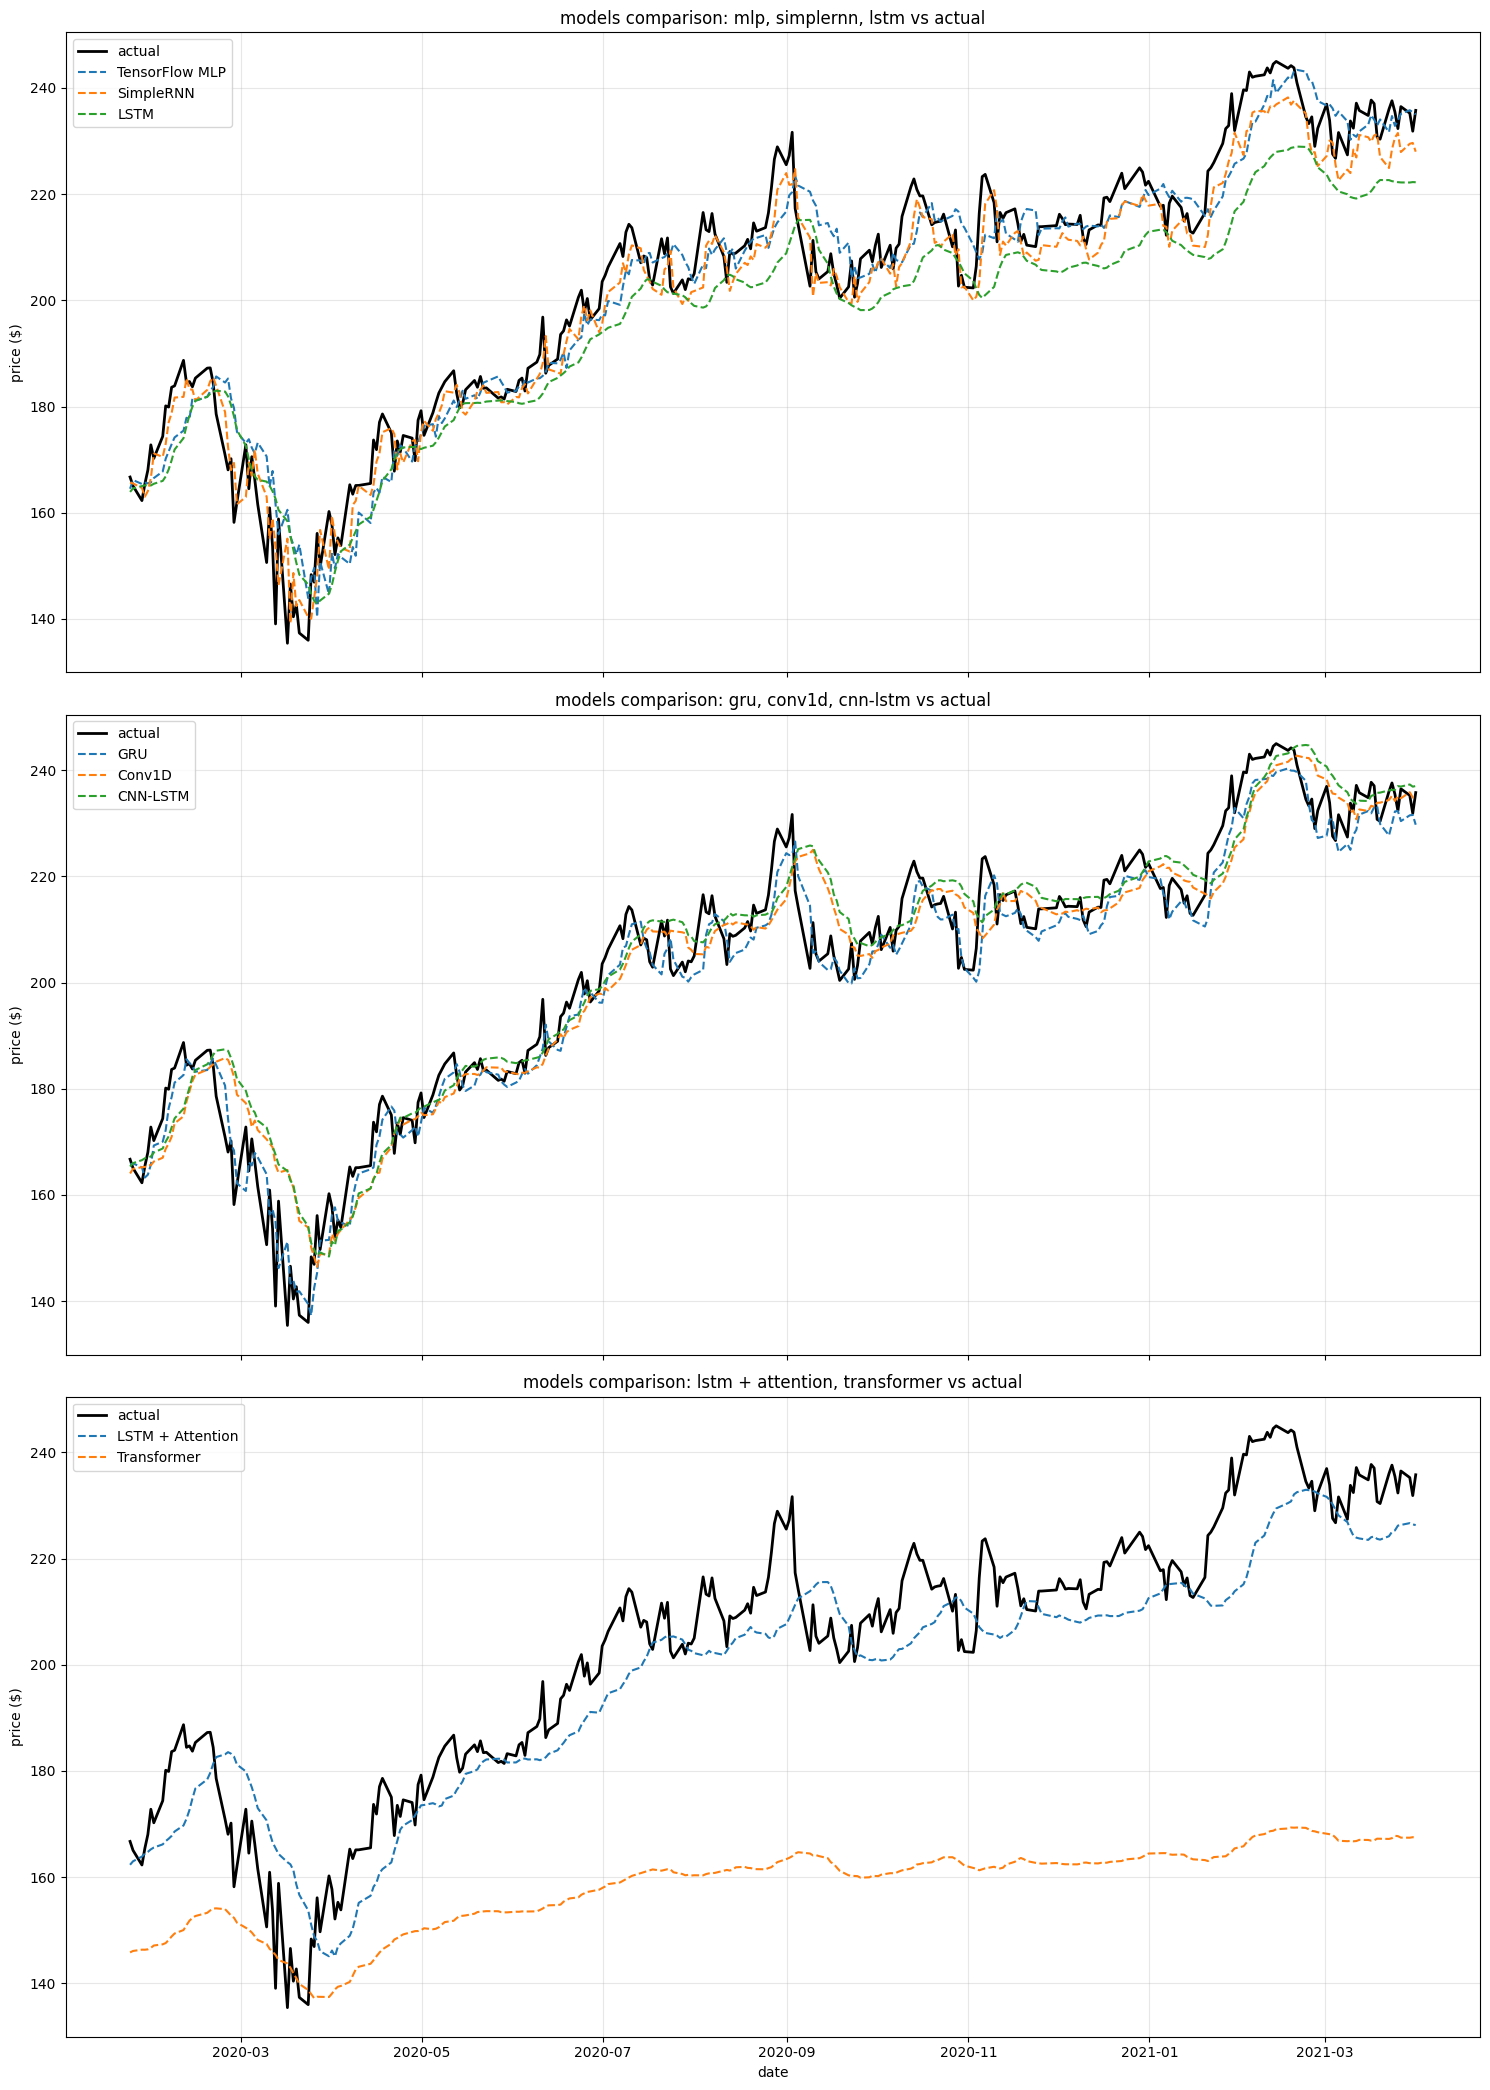

In [83]:
test_dates = ts.index[window_size + split_idx:]

fig, axes = plt.subplots(3, 1, figsize=(15, 21), sharex=True)

# Plot 1: MLP, SimpleRNN, LSTM
models_plot1 = ['TensorFlow MLP', 'SimpleRNN', 'LSTM']
axes[0].plot(test_dates, y_test_inv, label='actual', color='black', linewidth=2)
for index, row in comparison_df_plot[comparison_df_plot['Model'].isin(models_plot1)].iterrows():
    axes[0].plot(test_dates, row['Predictions'], label=row['Model'], linestyle='--')
axes[0].set_title('models comparison: mlp, simplernn, lstm vs actual')
axes[0].set_ylabel('price ($)')
axes[0].legend(loc='upper left')
axes[0].grid(alpha=0.3)

# Plot 2: GRU, Conv1D, CNN-LSTM
models_plot2 = ['GRU', 'Conv1D', 'CNN-LSTM']
axes[1].plot(test_dates, y_test_inv, label='actual', color='black', linewidth=2)
for index, row in comparison_df_plot[comparison_df_plot['Model'].isin(models_plot2)].iterrows():
    axes[1].plot(test_dates, row['Predictions'], label=row['Model'], linestyle='--')
axes[1].set_title('models comparison: gru, conv1d, cnn-lstm vs actual')
axes[1].set_ylabel('price ($)')
axes[1].legend(loc='upper left')
axes[1].grid(alpha=0.3)

# Plot 3: LSTM + Attention, Transformer
models_plot3 = ['LSTM + Attention', 'Transformer']
axes[2].plot(test_dates, y_test_inv, label='actual', color='black', linewidth=2)
for index, row in comparison_df_plot[comparison_df_plot['Model'].isin(models_plot3)].iterrows():
    axes[2].plot(test_dates, row['Predictions'], label=row['Model'], linestyle='--')
axes[2].set_title('models comparison: lstm + attention, transformer vs actual')
axes[2].set_xlabel('date')
axes[2].set_ylabel('price ($)')
axes[2].legend(loc='upper left')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [77]:
print(comparison_df_plot.drop(columns=['Predictions']).sort_values(by='MSE'))

              Model          MSE       RMSE        MAE
3               GRU    26.670820   5.164380   4.132085
1         SimpleRNN    31.768312   5.636339   4.623671
0    TensorFlow MLP    49.620190   7.044160   5.481302
4            Conv1D    58.227385   7.630687   5.773037
5          CNN-LSTM    60.938596   7.806318   5.845407
2              LSTM   108.045893  10.394513   8.723269
6  LSTM + Attention   112.073392  10.586472   8.795390
7       Transformer  2267.645138  47.619798  44.257906
